# 6.3 — DBSCAN
# Density-Based Spatial Clustering of Applications with Noise

## Why DBSCAN exists — the two problems it solves

K-Means and Hierarchical (Ward) both share a hidden assumption: **clusters are round blobs.** Both minimise inertia — which naturally produces circular boundaries around centroids. If your real clusters are crescent-shaped, ring-shaped, or interleaved — both algorithms fail badly.

Also — both K-Means and Hierarchical **force every single point into a cluster.** Even outliers. A customer who spends ₹80,000/month and visits once a year gets silently forced into whichever group is nearest — hiding the anomaly entirely.

**DBSCAN fixes both:**
- Finds clusters of **any shape** — follows density, not centroid distance
- Explicitly labels outliers as **noise (-1)** — never forces them into a cluster

## The analogy — how a crowd forms

Imagine Marina Beach in Chennai on a Sunday. People naturally form groups — families sitting together, cricket groups, food stall queues. How would you identify these groups without labels?

You'd look for **density.** Wherever people are packed closely together — that's a group. The sparse areas between groups — that's open space, not a group. The one person sitting 200 metres from everyone? He's not in any group. He's an **outlier.**

That's exactly DBSCAN's logic.

## The key insight — ε vs K

K-Means asks you to specify K — the number of clusters. But that's the answer you're trying to find. You're guessing at the output.

DBSCAN asks you to specify **ε (epsilon)** — how close is close enough to be neighbours. That's a question you *can* answer — it's a business/domain judgement about similarity, not a guess about structure.

The number of clusters that emerges from your ε definition is the data's answer, not your assumption.

## The Real World Problem

Meena's FreshMart data — but now she suspects:
1. There may be **irregularly shaped** customer groups (not round blobs)
2. A few customers are genuinely unusual — extreme spenders who don't fit any group
3. She wants those unusual customers **flagged**, not silently lumped into a cluster

K-Means cannot help with 1 or 3. DBSCAN handles both.

## Two Parameters

**ε (epsilon)** — the neighbourhood radius. How far around a point do you look for neighbours? Two points are neighbours if their distance ≤ ε.

**min_samples** — the minimum number of points (including itself) within ε for a point to be a **core point** — the heart of a dense region.

## Three Types of Points

Every point is classified as one of three types:

| Type | Definition | Cluster assignment |
|---|---|---|
| **Core point** | Has ≥ min_samples neighbours within ε (including itself) | Belongs to a cluster — starts or expands one |
| **Border point** | Has < min_samples neighbours within ε, BUT is within ε of a core point | Belongs to that core point's cluster |
| **Noise point** | Not a core point AND not within ε of any core point | Label = **-1** — true outlier, no cluster |

## The Algorithm — Step by Step

**Step 1** — Pick any unvisited point.  
**Step 2** — Count neighbours within ε.  
- Count ≥ min_samples → **core point** → start a new cluster  
- Count < min_samples → mark as noise for now (may be upgraded to border later)  

**Step 3** — If core point, **expand the cluster:**  
- Add all neighbours within ε to the cluster  
- For each neighbour that is also a core point → add *their* neighbours too  
- Keep expanding until no more reachable core points  

**Step 4** — Move to the next unvisited point. Repeat.  
**Step 5** — Any point still marked noise after all visits = true outlier (label -1).  

This expansion is why DBSCAN finds any shape — it doesn't draw a circle around a centroid, it **follows the density** wherever it leads.

## Why Any Shape Works

K-Means asks: *"what is the nearest centroid?"* → always round boundaries.

DBSCAN asks: *"is there a dense path connecting these two points?"* → follows any shape.

As long as a dense path exists — crescent, spiral, ring — DBSCAN traces along it.

## Key Concepts Table

| Concept | What it means |
|---|---|
| ε (epsilon) | Neighbourhood radius — how far to look for neighbours |
| min_samples | Minimum neighbours within ε to be a core point |
| Core point | ≥ min_samples neighbours within ε — dense region — starts/grows a cluster |
| Border point | < min_samples neighbours but within ε of a core — belongs to that cluster |
| Noise point | Not core, not near any core — label = -1 — true outlier |
| Density reachable | Two points connected via dense path — enables any shape |
| k-distance plot | Sort k-th nearest neighbour distances — elbow = good ε |
| Why ε ≠ K | ε is a domain judgement about similarity. K is a guess at the answer you don't know. |
| Varying density problem | One ε can't work for clusters of different densities |
| Full form | Density-Based Spatial Clustering of Applications with Noise |

In [1]:
# --- Imports ---
# DBSCAN: the clustering algorithm
# NearestNeighbors: used to compute k-distance plot for finding ε
# StandardScaler: mandatory — DBSCAN is distance-based, scale matters
# silhouette_score: cluster quality metric (exclude noise points)
# PCA: compress to 2D for visualisation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)
print("Imports done.")

Imports done.


## Step 1 — Generate FreshMart Dataset with Outliers

Same 3-group customer data as before — but now we add a small group of genuinely unusual customers that don't belong to any cluster.

In [2]:
# --- Generate dataset with intentional outliers ---
# Groups 1-3: same FreshMart segments as 6.1 and 6.2
# Outliers: extreme values in multiple features — genuinely unusual customers
#   These are customers K-Means would silently absorb into a cluster
#   DBSCAN will flag them as noise (-1)

g1 = np.random.multivariate_normal(
    mean=[250, 25, 12, 400],
    cov=np.diag([30**2, 8**2, 3**2, 80**2]), size=180)

g2 = np.random.multivariate_normal(
    mean=[800, 75, 3, 2500],
    cov=np.diag([80**2, 10**2, 1**2, 400**2]), size=160)

g3 = np.random.multivariate_normal(
    mean=[480, 55, 7, 1100],
    cov=np.diag([50**2, 12**2, 2**2, 200**2]), size=130)

# Outliers — extreme customers that don't fit any pattern
# e.g. very high income but almost never visit, or very low income but huge basket
outliers = np.array([
    [1100, 95, 1, 4800],   # Ultra premium — visits once a year, spends enormous amount
    [150,  90, 18, 3200],  # Paradox customer — low income but extremely high spending
    [950,  10, 15, 200],   # High income but very low spending score and tiny basket
    [600,  50, 1, 4500],   # Mid income but almost never visits, huge basket when they do
    [200,  85, 2, 2800],   # Low income, high score, rare visits — unusual combination
])

X_raw = np.vstack([g1, g2, g3, outliers])
df = pd.DataFrame(X_raw, columns=['annual_income_k', 'spending_score',
                                    'visit_frequency', 'avg_basket_size'])
df['annual_income_k'] = df['annual_income_k'].clip(100, 1200)
df['spending_score']  = df['spending_score'].clip(1, 100)
df['visit_frequency'] = df['visit_frequency'].clip(1, 20)
df['avg_basket_size'] = df['avg_basket_size'].clip(100, 5000)

# Scale — mandatory before DBSCAN, same reason as K-Means
# Distance-based algorithm — large-scale features dominate without scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print(f"Dataset: {df.shape}")
print(f"  Regular customers: {len(g1)+len(g2)+len(g3)}")
print(f"  Outliers injected: {len(outliers)}")
df.tail(8)

Dataset: (475, 4)
  Regular customers: 470
  Outliers injected: 5


,annual_income_k,spending_score,visit_frequency,avg_basket_size
467,459.459286,41.731544,6.570158,881.806714
468,518.983027,70.723705,9.791368,1038.393143
469,469.538906,34.798742,5.388260,987.566395
470,1100.000000,95.000000,1.000000,4800.000000
471,150.000000,90.000000,18.000000,3200.000000
472,950.000000,10.000000,15.000000,200.000000
473,600.000000,50.000000,1.000000,4500.000000
474,200.000000,85.000000,2.000000,2800.000000


## Step 2 — Find ε Using the K-Distance Plot

The k-distance plot is the DBSCAN equivalent of the elbow method.

**How it works:**
1. For every point, find its distance to its k-th nearest neighbour (k = min_samples - 1)
2. Sort all these distances from smallest to largest
3. Plot them
4. Find the **elbow** — where distances start rising sharply

Points before the elbow are in dense regions (their k-th neighbour is close). Points after the elbow are in sparse regions (their k-th neighbour is far). The elbow distance = your ε.

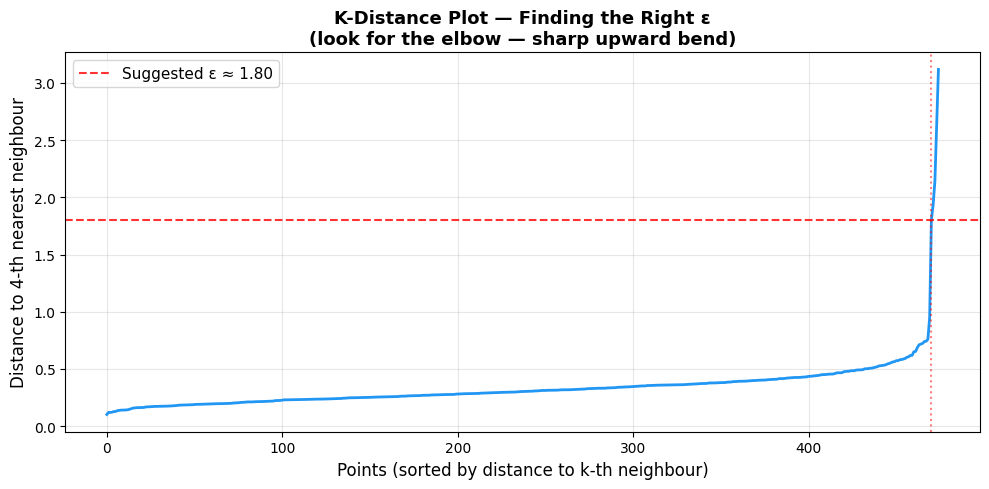

Suggested ε from k-distance plot: 1.805
Points before elbow (dense region): 470
Points after elbow (sparse/outlier region): 5

We'll try ε=1.80 and also experiment around it.


In [3]:
# --- K-distance plot to find ε ---
# min_samples rule of thumb: 2 × number of features (here 4 features → min_samples=8)
# or at minimum 3-5 for small datasets
# We'll try min_samples=5 (common default for medium datasets)

min_samples = 5
k = min_samples - 1  # look at k-th nearest neighbour distance

# NearestNeighbors: for each point, find distances to k nearest neighbours
# We use k+1 because it includes the point itself
nbrs = NearestNeighbors(n_neighbors=k+1).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Take the distance to the k-th neighbour (last column, excluding self at index 0)
k_distances = np.sort(distances[:, -1])  # sort ascending

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_distances, color='#2196F3', linewidth=2)
ax.set_xlabel('Points (sorted by distance to k-th neighbour)', fontsize=12)
ax.set_ylabel(f'Distance to {k}-th nearest neighbour', fontsize=12)
ax.set_title('K-Distance Plot — Finding the Right ε\n(look for the elbow — sharp upward bend)', 
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# Find approximate elbow — largest second derivative
second_deriv = np.diff(k_distances, n=2)
elbow_idx = np.argmax(second_deriv) + 2
elbow_eps  = k_distances[elbow_idx]

ax.axhline(y=elbow_eps, color='red', linestyle='--', alpha=0.8,
           label=f'Suggested ε ≈ {elbow_eps:.2f}')
ax.axvline(x=elbow_idx, color='red', linestyle=':', alpha=0.5)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"Suggested ε from k-distance plot: {elbow_eps:.3f}")
print(f"Points before elbow (dense region): {elbow_idx}")
print(f"Points after elbow (sparse/outlier region): {len(k_distances) - elbow_idx}")
print(f"\nWe'll try ε={elbow_eps:.2f} and also experiment around it.")

## Step 3 — Train DBSCAN

In [4]:
# --- Train DBSCAN ---
# eps: neighbourhood radius — from k-distance plot
# min_samples: minimum neighbours to be a core point
# metric='euclidean': standard distance metric (same as K-Means)
# No random_state needed — DBSCAN is fully deterministic (no random init)

eps_val = round(elbow_eps, 2)

db = DBSCAN(eps=eps_val, min_samples=min_samples, metric='euclidean')
db_labels = db.fit_predict(X_scaled)

df['db_cluster'] = db_labels

# -1 = noise points (outliers). Cluster numbers start from 0.
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()

print(f"ε = {eps_val}, min_samples = {min_samples}")
print(f"Clusters found: {n_clusters}")
print(f"Noise points (outliers): {n_noise}")
print(f"\nCluster distribution:")
print(df['db_cluster'].value_counts().sort_index().rename({-1: '-1 (noise)'}))

# Silhouette score — computed only on non-noise points
# Why exclude noise: silhouette is undefined for points with no cluster
mask = db_labels != -1
if mask.sum() > 0 and len(set(db_labels[mask])) > 1:
    sil = silhouette_score(X_scaled[mask], db_labels[mask])
    print(f"\nSilhouette score (non-noise points only): {sil:.3f}")

ε = 1.8, min_samples = 5
Clusters found: 1
Noise points (outliers): 3

Cluster distribution:
db_cluster
-1 (noise)      3
0             472
Name: count, dtype: int64


## Step 4 — Visualise: Clusters and Noise Points

In [5]:
# --- PCA for 2D visualisation ---
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Variance explained: 92.9%


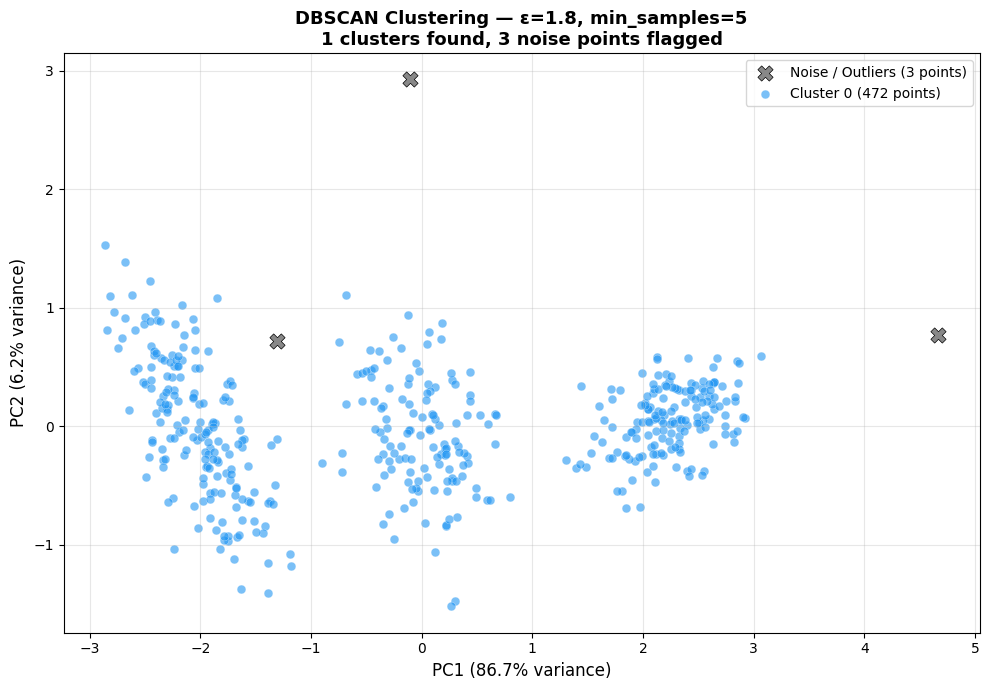

Grey X markers = customers DBSCAN refused to put in any cluster.
K-Means would have silently absorbed all of these into a cluster.


In [6]:
# --- Scatter plot: DBSCAN clusters ---
# Noise points (label=-1) shown as grey X markers — easy to spot
# Each cluster shown in a distinct colour

fig, ax = plt.subplots(figsize=(10, 7))

cluster_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#E91E63']
unique_labels = sorted(set(db_labels))

for label in unique_labels:
    mask = db_labels == label
    if label == -1:
        # Noise points — grey X markers, larger and distinct
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c='#888888', marker='X', s=120, zorder=5,
                   label=f'Noise / Outliers ({mask.sum()} points)', edgecolors='black', linewidth=0.5)
    else:
        col = cluster_colors[label % len(cluster_colors)]
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=col, alpha=0.6, s=40, edgecolors='white', linewidth=0.3,
                   label=f'Cluster {label} ({mask.sum()} points)')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title(f'DBSCAN Clustering — ε={eps_val}, min_samples={min_samples}\n'
             f'{n_clusters} clusters found, {n_noise} noise points flagged',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Grey X markers = customers DBSCAN refused to put in any cluster.")
print("K-Means would have silently absorbed all of these into a cluster.")

## Step 5 — Examine the Noise Points (Outliers)

This is one of DBSCAN's most valuable outputs. The noise points are not bad data — they are **genuinely unusual customers** that Meena should handle differently.

In [7]:
# --- Inspect noise points ---
# These are the customers DBSCAN flagged as outliers
# They don't fit any dense group — not bad data, just genuinely unusual

noise_df = df[df['db_cluster'] == -1].copy()
print(f"=== Flagged Outliers ({len(noise_df)} customers) ===")
print(noise_df[['annual_income_k', 'spending_score', 'visit_frequency', 
                'avg_basket_size']].round(0).to_string())

print("\n=== Dataset averages for comparison ===")
print(df[['annual_income_k', 'spending_score', 'visit_frequency', 
          'avg_basket_size']].mean().round(0))

print("\n=== Business interpretation ===")
print("These customers don't fit any of the standard segments.")
print("Meena should contact them personally rather than send mass offers.")
print("K-Means would have silently merged them into the nearest cluster — hiding them.")

=== Flagged Outliers (3 customers) ===
     annual_income_k  spending_score  visit_frequency  avg_basket_size
470           1100.0            95.0              1.0           4800.0
471            150.0            90.0             18.0           3200.0
472            950.0            10.0             15.0            200.0

=== Dataset averages for comparison ===
annual_income_k     504.0
spending_score       51.0
visit_frequency       8.0
avg_basket_size    1345.0
dtype: float64

=== Business interpretation ===
These customers don't fit any of the standard segments.
Meena should contact them personally rather than send mass offers.
K-Means would have silently merged them into the nearest cluster — hiding them.


## Step 6 — Effect of ε: What Happens When You Change It

ε controls how strict your definition of density is. This is the most important parameter to understand intuitively.

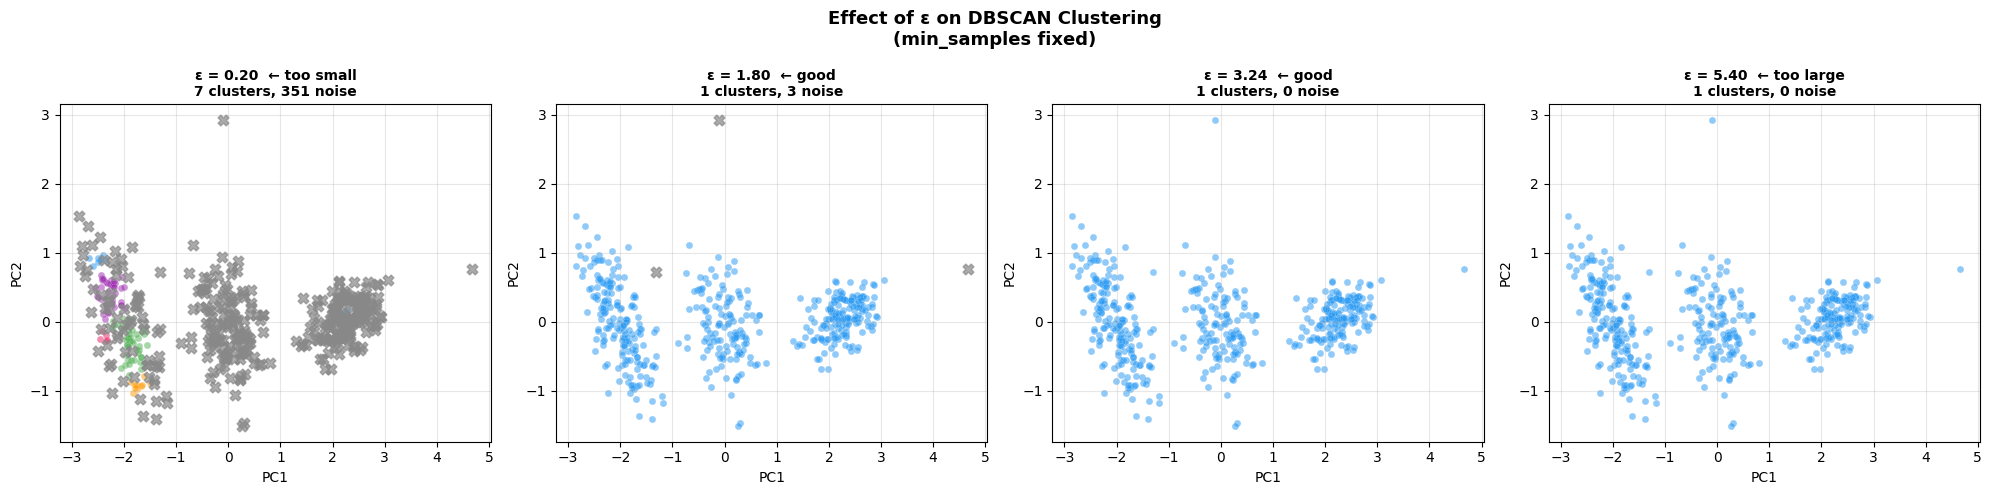

Left (ε too small):  definition of 'close' too strict → most points become noise
Right (ε too large): definition of 'close' too loose → everything merges into one cluster
Middle-right (good ε): natural clusters + genuine outliers flagged


In [8]:
# --- Effect of different ε values ---
# Too small ε: definition of 'close' is too strict
#   → most points have too few neighbours → everything becomes noise
# Too large ε: definition of 'close' is too loose
#   → everything is a neighbour of everything → one giant cluster
# Right ε: natural clusters emerge, outliers get flagged

eps_values = [0.2, eps_val, eps_val * 1.8, eps_val * 3.0]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, eps in zip(axes, eps_values):
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
    n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
    n_ns   = (labels == -1).sum()

    for label in sorted(set(labels)):
        mask = labels == label
        if label == -1:
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c='#888888', marker='X', s=60, zorder=5, alpha=0.7)
        else:
            col = cluster_colors[label % len(cluster_colors)]
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c=col, alpha=0.5, s=25, edgecolors='white', linewidth=0.2)

    verdict = '← too small' if eps < eps_val * 0.7 else ('← too large' if eps > eps_val * 2.2 else '← good')
    ax.set_title(f'ε = {eps:.2f}  {verdict}\n{n_cl} clusters, {n_ns} noise',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.grid(alpha=0.3)

plt.suptitle('Effect of ε on DBSCAN Clustering\n(min_samples fixed)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Left (ε too small):  definition of 'close' too strict → most points become noise")
print("Right (ε too large): definition of 'close' too loose → everything merges into one cluster")
print("Middle-right (good ε): natural clusters + genuine outliers flagged")

## Step 7 — Compare: DBSCAN vs K-Means on Same Data

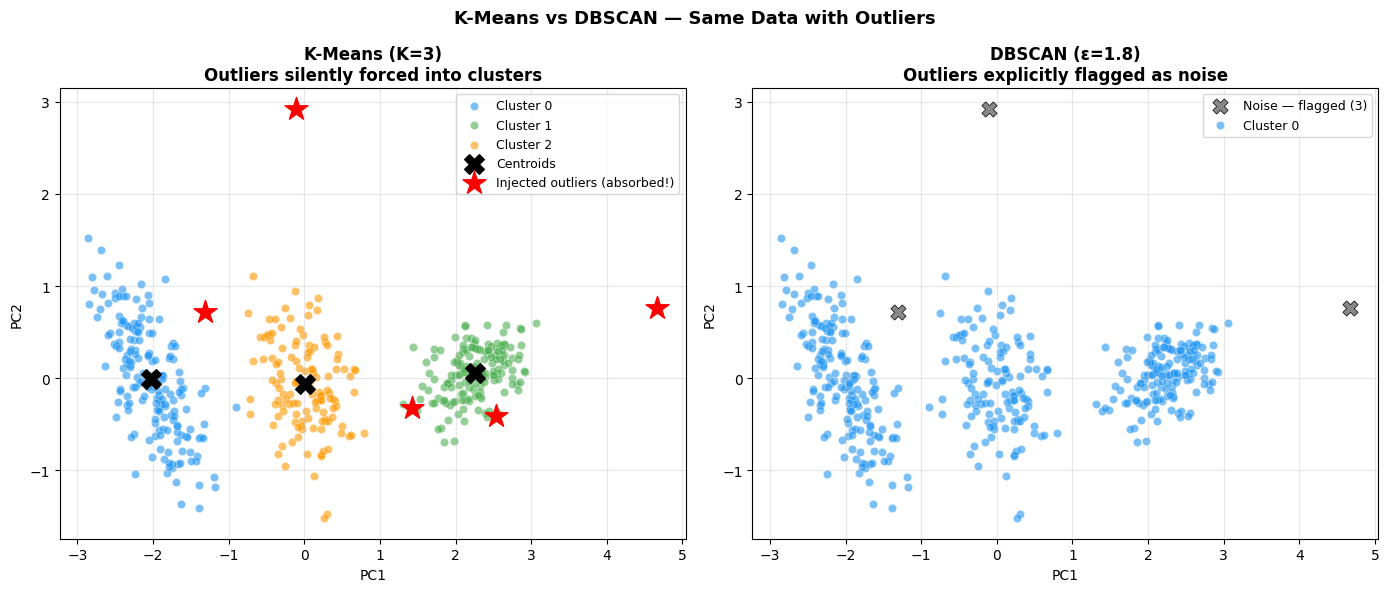

Red stars in K-Means panel = injected outliers. K-Means absorbed them into normal clusters.
Grey X in DBSCAN panel = same outliers. DBSCAN refused to put them in any cluster.


In [9]:
# --- DBSCAN vs K-Means side by side ---
# K-Means: forced to assign every point to a cluster — outliers get absorbed
# DBSCAN: explicitly labels outliers as -1 — nothing is forced

from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
km_labels = km.fit_predict(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# K-Means plot
km_colors = ['#2196F3', '#4CAF50', '#FF9800']
for k in range(3):
    mask = km_labels == k
    ax1.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=km_colors[k], alpha=0.6, s=35, edgecolors='white', linewidth=0.3,
                label=f'Cluster {k}')
centroids_2d = pca.transform(km.cluster_centers_)
ax1.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroids')
# Mark where injected outliers ended up
outlier_indices = list(range(len(df) - len(outliers), len(df)))
ax1.scatter(X_2d[outlier_indices, 0], X_2d[outlier_indices, 1],
            c='red', marker='*', s=300, zorder=6, label='Injected outliers (absorbed!)')
ax1.set_title('K-Means (K=3)\nOutliers silently forced into clusters',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9); ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2'); ax1.grid(alpha=0.3)

# DBSCAN plot
for label in sorted(set(db_labels)):
    mask = db_labels == label
    if label == -1:
        ax2.scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c='#888888', marker='X', s=120, zorder=5,
                    label=f'Noise — flagged ({mask.sum()})', edgecolors='black', linewidth=0.5)
    else:
        col = cluster_colors[label % len(cluster_colors)]
        ax2.scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=col, alpha=0.6, s=35, edgecolors='white', linewidth=0.3,
                    label=f'Cluster {label}')
ax2.set_title(f'DBSCAN (ε={eps_val})\nOutliers explicitly flagged as noise',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9); ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.grid(alpha=0.3)

plt.suptitle('K-Means vs DBSCAN — Same Data with Outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Red stars in K-Means panel = injected outliers. K-Means absorbed them into normal clusters.")
print("Grey X in DBSCAN panel = same outliers. DBSCAN refused to put them in any cluster.")

## Step 8 — Cluster Profiles (Non-Noise Points)

In [10]:
# --- Analyse non-noise clusters ---
# Same as K-Means: group by cluster, compute mean of each feature
# Exclude noise points (-1) from this analysis

regular = df[df['db_cluster'] != -1].copy()
profile = regular.groupby('db_cluster')[['annual_income_k', 'spending_score',
                                          'visit_frequency', 'avg_basket_size']].mean().round(1)

print("=== DBSCAN Cluster Profiles (noise excluded) ===")
print(profile)

print("\n=== Noise point profile ===")
noise_profile = df[df['db_cluster'] == -1][['annual_income_k', 'spending_score',
                                              'visit_frequency', 'avg_basket_size']].mean().round(1)
print(noise_profile)
print("\nNotice: noise points have extreme feature combinations — they don't fit any cluster's pattern.")

=== DBSCAN Cluster Profiles (noise excluded) ===
            annual_income_k  spending_score  visit_frequency  avg_basket_size
db_cluster                                                                   
0                     502.7            50.9              7.6           1335.8

=== Noise point profile ===
annual_income_k     733.3
spending_score       65.0
visit_frequency      11.3
avg_basket_size    2733.3
dtype: float64

Notice: noise points have extreme feature combinations — they don't fit any cluster's pattern.


## DBSCAN vs K-Means vs Hierarchical — Full Comparison

| | K-Means | Hierarchical | DBSCAN |
|---|---|---|---|
| **Specify K upfront?** | Yes | No | No |
| **Finds any shape?** | No — round only | Ward=No, Single=yes (chaining) | Yes — follows density |
| **Handles outliers?** | No — forces all into clusters | No | Yes — labels them -1 |
| **Sensitive to scale?** | Yes | Yes | Yes |
| **Parameter to tune** | K | linkage method | ε and min_samples |
| **How to tune** | Elbow + Silhouette | Dendrogram gap | K-distance plot |
| **Reproducible?** | No (random init) | Yes | Yes |
| **Scales to large data?** | Yes | No | Yes |
| **Varying density problem?** | No | No | Yes — one ε struggles |
| **Best for** | Large data, round clusters | Small data, exploring structure | Any shape, outlier detection |

## Key Weaknesses of DBSCAN

| Weakness | Why | Workaround |
|---|---|---|
| Varying density | One ε can't capture both dense and sparse clusters | HDBSCAN (advanced variant) |
| Hard to tune | Wrong ε → very different results, no clean method | K-distance plot + experiment |
| Still needs scaling | Distance-based — large features dominate | StandardScaler mandatory |
| High dimensions | Curse of dimensionality — everything equidistant | Use PCA first to reduce dimensions |

## Summary Table

| Concept | What it means |
|---|---|
| DBSCAN full form | Density-Based Spatial Clustering of Applications with Noise |
| ε (epsilon) | Neighbourhood radius — how far to look for neighbours |
| min_samples | Minimum neighbours within ε to qualify as a core point |
| Core point | ≥ min_samples neighbours within ε — dense region — starts/expands cluster |
| Border point | Near a core point but not dense enough itself — belongs to core's cluster |
| Noise point | Not core, not near any core — label -1 — true outlier |
| Why any shape | Follows density path between points — not centroid distance |
| K-distance plot | Sort k-th nearest neighbour distances — elbow = good ε |
| ε vs K | ε is a domain judgement about similarity — K is a guess at unknown answer |
| Varying density | One ε struggles when clusters have different densities |
| Silhouette with noise | Compute only on non-noise points — noise has no cluster to measure against |
| Scaling mandatory | DBSCAN is distance-based — unscaled features produce wrong neighbourhoods |

## Practice Task

Arjun is a data analyst at a Kochi taxi company. He has GPS trip data for 400 trips:
- `pickup_lat`, `pickup_lon` — pickup coordinates
- `trip_duration_min` — trip duration in minutes
- `fare_inr` — fare in ₹

He wants to find natural pickup hotspots (dense pickup areas) and flag unusual trips that don't fit any pattern.

**Your tasks:**
1. Generate 400 synthetic trips with 3 natural pickup hotspots (e.g. airport, city centre, railway station) and ~10 unusual trips
2. Scale the features
3. Plot the k-distance plot to find ε
4. Train DBSCAN with your chosen ε and min_samples
5. Report: how many hotspots found? How many unusual trips flagged?
6. Visualise clusters and noise points with PCA
7. Show the profiles of the flagged unusual trips — what makes them unusual?
8. Compare with K-Means (K=3) — does K-Means flag any outliers? What happens to them?

In [11]:
# YOUR CODE HERE

# Step 1: Generate taxi trip data with 3 hotspots + unusual trips

# Step 2: Scale

# Step 3: K-distance plot

# Step 4: DBSCAN

# Step 5: Report clusters and noise

# Step 6: PCA visualisation

# Step 7: Noise point profiles

# Step 8: K-Means comparison